# Phase 2 feature exploration: electrogram features for rotor-adjacency prediction

This notebook is the hands-on companion to `docs/PHASE2_METHODOLOGY.md` §7-8. That doc
explains the *biophysics* reasoning behind each feature; this notebook is for exploring them
the way a data scientist would — look at the raw signals directly, check distributions and
correlations, and try new feature/model ideas — without needing any EP domain background to
get started.

**Data**: raw `Vm` traces + mesh + ground-truth labels for all 3 independently-induced rotors
(`opencarp/notebook_data/rotor{A,B,C}.npz`), plus the electrode-cluster feature CSVs already
computed by `opencarp/extract_cluster_features.py` at `k=1..8`. These files are gitignored
(regenerable, ~21MB each) — if they're missing, regenerate with:

```bash
docker run --rm -v $(pwd)/runs:/shared -v $(pwd):/opencarp_repo \
    docker.opencarp.org/opencarp/opencarp:latest \
    python3 /opencarp_repo/export_for_notebook.py <sim_dir> <mesh_prefix> --out notebook_data/rotorX.npz
```

**How to read this notebook**: Sections 1-2 ground the four existing features (bipolar
amplitude, fractionation, LAT, dominant frequency) in the actual raw signals, and in
particular work through `lat_spread_ms` concretely with real traces. Sections 3-4 are
standard EDA (distributions, correlations, a PCA view). Section 5 is a feature-engineering
playground — one new feature fully implemented, two more scaffolded for you to finish.
Section 6 compares a couple of alternative model formulations using a proper `GroupKFold`
(rotor-as-group) cross-validation, the idiomatic sklearn way to do what
`opencarp/train_leave_one_rotor_out.py` did by hand.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
DATA_DIR = Path("notebook_data")
ROTORS = ["A", "B", "C"]

raw = {r: np.load(DATA_DIR / f"rotor{r}.npz") for r in ROTORS}
cluster_df = {r: pd.read_csv(DATA_DIR / f"rotor{r}_cluster_features.csv") for r in ROTORS}

for r in ROTORS:
    vm = raw[r]["vm"]
    n_pos = raw[r]["ablation_target"].sum()
    print(f"Rotor {r}: vm {vm.shape}, {n_pos} ablation-target nodes / {vm.shape[0]} total")

Rotor A: vm (15876, 401), 823 ablation-target nodes / 15876 total
Rotor B: vm (15876, 401), 617 ablation-target nodes / 15876 total


Rotor C: vm (15876, 401), 516 ablation-target nodes / 15876 total


## 1. Ground the features in the raw signal

Before trusting any engineered feature, look at what it's actually built from. Let's pull one
ablation-target site and one background site (far from the core) from rotor A and just plot
their raw `Vm(t)` traces.

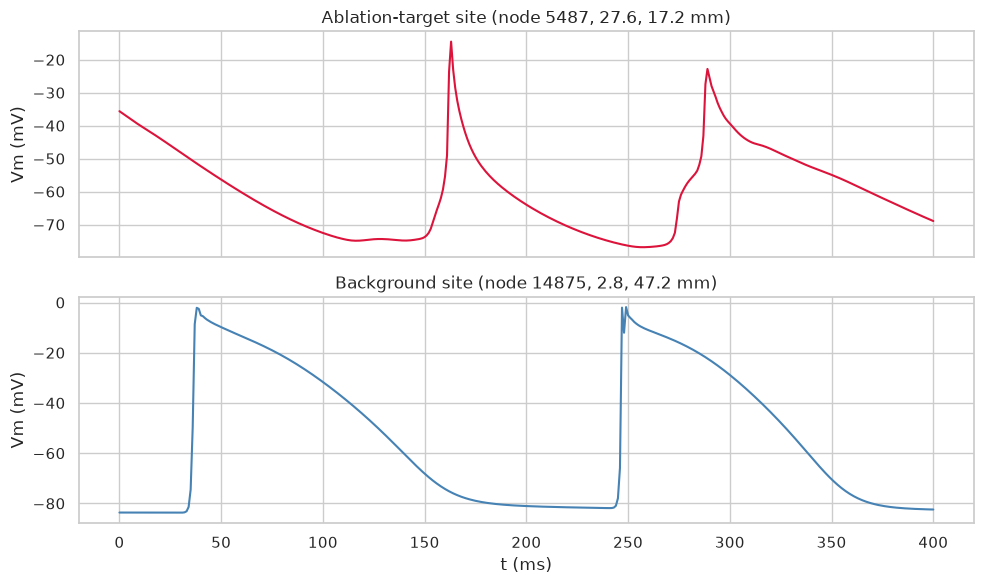

In [2]:
FS_HZ = 1000.0  # 1 sample/ms

def node_index(pts, x_mm, y_mm):
    d = np.hypot(pts[:, 0] - x_mm * 1000, pts[:, 1] - y_mm * 1000)
    return int(np.argmin(d))

pts_A = raw["A"]["pts"]
labels_A = raw["A"]["ablation_target"]
vm_A = raw["A"]["vm"]
t_A = raw["A"]["t"]

target_ids = np.where(labels_A)[0]
background_ids = np.where(~labels_A)[0]

# an ablation-target site near the trajectory centroid, and a background site far from it --
# excluding a margin near the mesh edge (see the "gotcha" callout after Section 2: a
# neighbor-offset bug, since fixed, made near-edge sites unreliable for this kind of example)
MARGIN_UM = 6 * 400  # keep the same margin extract_cluster_features.py now uses
edge_dist = np.minimum.reduce([pts_A[:, 0], 50000 - pts_A[:, 0], pts_A[:, 1], 50000 - pts_A[:, 1]])
interior = edge_dist > MARGIN_UM

traj_x, traj_y = raw["A"]["traj_x"].mean(), raw["A"]["traj_y"].mean()
target_site = target_ids[np.argmin(np.hypot(pts_A[target_ids, 0] - traj_x, pts_A[target_ids, 1] - traj_y))]
background_interior_ids = background_ids[interior[background_ids]]
background_site = background_interior_ids[np.argmax(
    np.hypot(pts_A[background_interior_ids, 0] - traj_x, pts_A[background_interior_ids, 1] - traj_y))]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_A, vm_A[target_site], color="crimson")
axes[0].set_title(f"Ablation-target site (node {target_site}, "
                   f"{pts_A[target_site,0]/1000:.1f}, {pts_A[target_site,1]/1000:.1f} mm)")
axes[1].plot(t_A, vm_A[background_site], color="steelblue")
axes[1].set_title(f"Background site (node {background_site}, "
                   f"{pts_A[background_site,0]/1000:.1f}, {pts_A[background_site,1]/1000:.1f} mm)")
for ax in axes:
    ax.set_ylabel("Vm (mV)")
axes[1].set_xlabel("t (ms)")
fig.tight_layout()

**What to look for**: count the depolarizations (upward swings) in each trace over the 400ms
window — both sites should show a similar *number* of beats (they're on the same rotor, same
rough cycle length), but look at the *shape* of each swing. Near the core, wavefronts can
arrive from inconsistent directions beat to beat, so swings are often more ragged/variable in
shape and timing than a site the wave sweeps through cleanly and repeatedly. This is the raw
material `fractionation` and `bipolar_amplitude` are trying to summarize into single numbers
— worth deciding for yourself whether they're summarizing it *well*.

## 2. `lat_spread_ms`, made concrete

This is the feature the README calls "the biggest single win," and it's worth actually
seeing why. Recall: for a candidate site, we compute each of its up-to-8 local neighbors'
own LAT (time of steepest downstroke), and `lat_spread_ms = max(LAT) - min(LAT)` across the
whole cluster (candidate + neighbors).

Let's build one real cluster near the core and one real cluster far from it, plot every
site's trace *overlaid*, mark each site's own LAT with a vertical line, and just look at how
spread out those lines are.

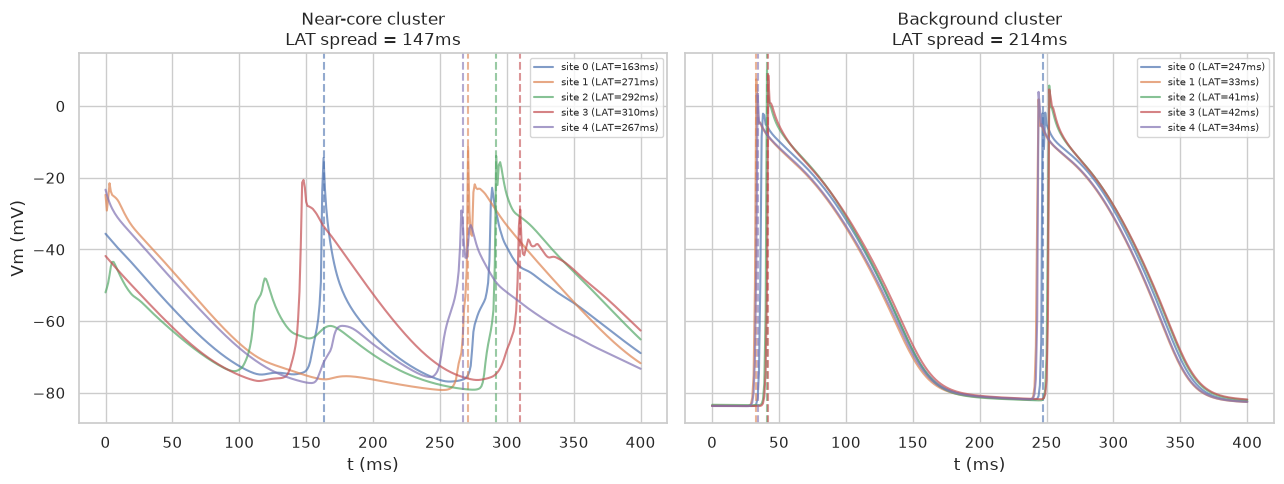

In [3]:
OFFSET_NODES = 5  # 2mm, same as extract_cluster_features.py

def cluster_node_ids(pts, nx, center_id, k=4):
    # same 4-cardinal-direction neighbor pattern as extract_cluster_features.py's k=4
    ix = center_id % nx
    iy = center_id // nx
    dirs = [(OFFSET_NODES, 0), (0, OFFSET_NODES), (-OFFSET_NODES, 0), (0, -OFFSET_NODES)][:k]
    ids = [center_id]
    for dx, dy in dirs:
        jx, jy = ix + dx, iy + dy
        jx = min(max(jx, 0), nx - 1)
        jy = min(max(jy, 0), pts.shape[0] // nx - 1)
        ids.append(jy * nx + jx)
    return ids

def compute_lat(unipolar, dt_ms):
    d = np.diff(unipolar)
    return int(np.argmin(d)) * dt_ms

nx = len(np.unique(pts_A[:, 0]))
dt_ms = float(t_A[1] - t_A[0])

near_core_cluster = cluster_node_ids(pts_A, nx, target_site)
far_cluster = cluster_node_ids(pts_A, nx, background_site)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cluster, title in [(axes[0], near_core_cluster, "Near-core cluster"),
                             (axes[1], far_cluster, "Background cluster")]:
    lats = []
    for i, node in enumerate(cluster):
        lat = compute_lat(vm_A[node], dt_ms)
        lats.append(lat)
        ax.plot(t_A, vm_A[node], alpha=0.7, label=f"site {i} (LAT={lat:.0f}ms)")
        ax.axvline(lat, color=ax.lines[-1].get_color(), linestyle="--", alpha=0.6)
    spread = max(lats) - min(lats)
    ax.set_title(f"{title}\nLAT spread = {spread:.0f}ms")
    ax.set_xlabel("t (ms)")
    ax.legend(fontsize=7, loc="upper right")
axes[0].set_ylabel("Vm (mV)")
fig.tight_layout()

Compare the vertical dashed lines (each site's own LAT) between the two panels. In the
background cluster, all 5 sites' LAT lines should land close together — the wave sweeps
through that whole neighborhood at almost the same time, because it's an ordinary planar-ish
wavefront passing through. Near the core, the lines are noticeably more scattered — some
sites in that same small neighborhood activate meaningfully earlier or later than others,
because the wavefront doesn't sweep through consistently; it's curling around a pivot right
there. That scatter, quantified as `max - min`, is `lat_spread_ms`. It's a *relative*, or
relational, feature — not "how does this site look" but "how much does this neighborhood
disagree with itself about when things happened" — which is why it tracks the core's
topological signature (§4 of the methodology doc) so much better than any single-site
feature could.

Try running the cell above with different sites (change `target_site`/`background_site`, or
try `background_ids[np.argmin(...)]` for a background site *closer* to the core) to build
more intuition for how sharp this distinction is, and where it starts to blur.

> **A real bug this notebook caught.** The first version of the background-site cell above
> didn't exclude sites near the mesh edge, and happened to pick the exact corner (0, 50mm).
> Its `lat_spread_ms` came out to 208ms — *larger* than the near-core cluster's 147ms,
> backwards from the whole point of this section. Digging in: `extract_cluster_features.py`'s
> edge-handling mirrored out-of-bounds neighbor offsets back into the mesh, but at a
> boundary, the "east" and "west" (or "north"/"south") directions can mirror onto the exact
> same node — so a "cluster of 5 distinct local electrodes" was actually only 2 genuinely
> different points, with 3 duplicates, at every site within one neighbor-offset of a mesh
> edge. That's 100 of 676 candidate sites per rotor (~15%) — none of them ever
> ablation-target-positive (the induced cores never sat near a domain edge in any of our 3
> runs), so it added noise to background-class features only. Fixed in
> `extract_cluster_features.py` by simply not sampling candidates that close to the edge
> (576 candidates now, and also more physically realistic — a real catheter wouldn't probe
> literally at the tissue boundary either). Re-running the full pipeline with the fix moved
> the headline leave-one-rotor-out numbers by about 0.01-0.03 AUC at each k — the qualitative
> story (k=2 as the clear peak) held up, but it was worth checking rather than assuming.

## 3. Feature distributions across all 3 rotors

Now the standard EDA pass. Pool all three rotors' `k=4` electrode features (a physically
realistic small cross/grid catheter) into one dataframe, and look at how each feature's
distribution differs between ablation-target and background sites.

1728 total sites, 79 positive (4.6%)


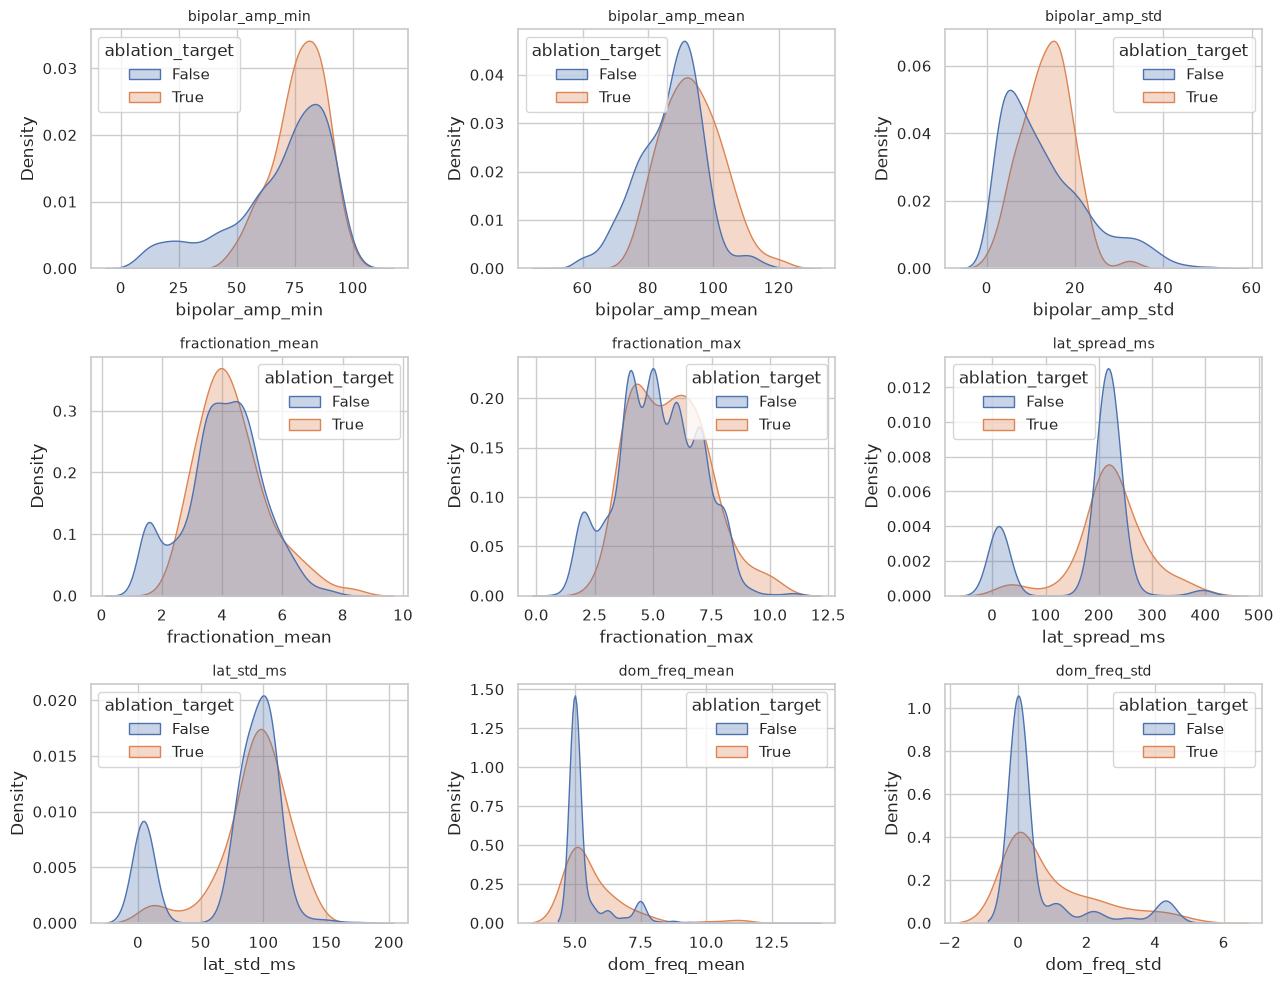

In [4]:
FEATURES = [
    "bipolar_amp_min", "bipolar_amp_mean", "bipolar_amp_std",
    "fractionation_mean", "fractionation_max",
    "lat_spread_ms", "lat_std_ms",
    "dom_freq_mean", "dom_freq_std",
]

k4 = pd.concat(
    [cluster_df[r][cluster_df[r]["k"] == 4].assign(rotor=r) for r in ROTORS],
    ignore_index=True,
)
print(f"{len(k4)} total sites, {k4['ablation_target'].sum()} positive "
      f"({k4['ablation_target'].mean():.1%})")

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, feat in zip(axes.ravel(), FEATURES):
    sns.kdeplot(data=k4, x=feat, hue="ablation_target", ax=ax, common_norm=False, fill=True, alpha=0.3)
    ax.set_title(feat, fontsize=10)
fig.tight_layout()

Look for: does the orange (or blue, depending on seaborn's default) curve for
`ablation_target=True` sit visibly shifted from the `False` curve, or are they nearly
on top of each other? A feature whose two curves fully overlap isn't carrying much signal on
its own (even if it still helps the model in combination with others) — worth checking this
against the permutation-importance ranking from `opencarp/train_electrogram_classifier.py`'s
output (`results/phase2_reentry_2026-08-20/classifier_results.png`) to see if your visual
read matches what the model actually leaned on.

## 3A. `fractionation` under the microscope

The two `fractionation_*` panels above overlap almost completely. Before writing the feature
off, three checks — the same kind of "look at the raw signal" pass that caught the
`lat_spread_ms` bug in Section 2:

1. **Is the count confounded by how many beats land in the window?** `fractionation` counts
   direction reversals over the *whole* ~400 ms trace. If a near-core site simply activates
   one extra time, its count goes up for a reason that has nothing to do with signal
   complexity. Normalising by the number of activations should remove that.
2. **What do the raw electrograms actually look like**, target vs background?
3. **Where does the feature sit spatially** relative to the rotor core path?

                frac_raw       n_activations       frac_per_beat      
                    mean   std          mean   std          mean   std
ablation_target                                                       
False               3.97  1.64          1.77  0.42          2.26  0.90
True                4.34  1.55          1.72  0.53          2.74  1.29

correlation with distance-to-core:
frac_raw        -0.130
frac_per_beat   -0.157
n_activations   -0.037
dtype: float64


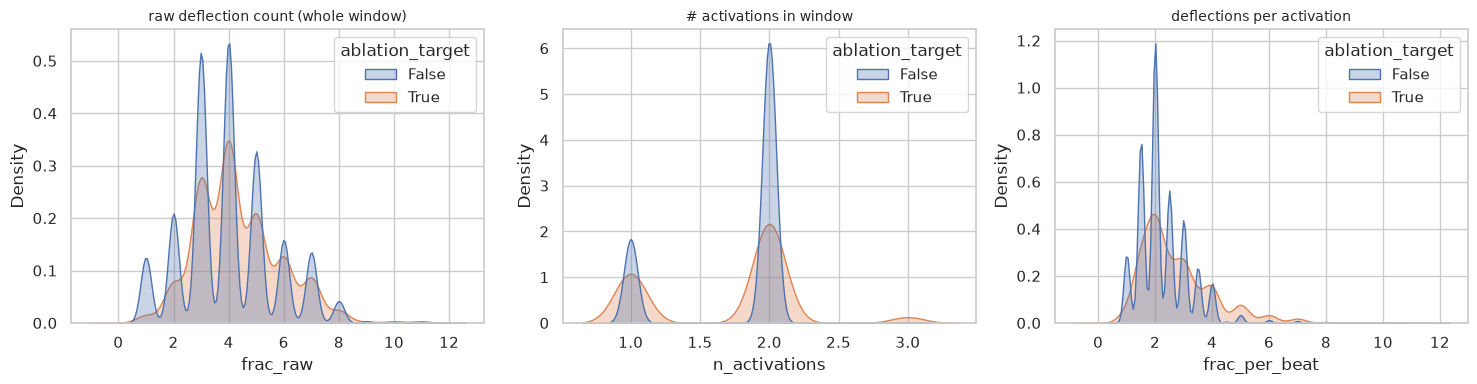

In [5]:
import numpy as np

FS_HZ = 1000.0
OFFSET_NODES = 5           # 2 mm, same as extract_cluster_features.py
THRESH_FRAC = 0.05         # fractionation deriv threshold, same as the pipeline
BORDER = OFFSET_NODES      # mask a ring this wide when mapping (no east neighbour there)

def grid_shape(pts):
    return len(np.unique(pts[:, 0])), len(np.unique(pts[:, 1]))

def core_distance_mm(pts, tx, ty):
    # min distance from every node to any point on the rotor-core trajectory
    return np.sqrt((pts[:, 0][:, None] - tx[None, :]) ** 2
                   + (pts[:, 1][:, None] - ty[None, :]) ** 2).min(axis=1) / 1000.0

def bipolar_east(vm, nx, ny):
    # node minus its neighbour OFFSET_NODES to the east; last OFFSET_NODES columns -> NaN
    v = vm.reshape(ny, nx, -1).astype(float)
    bp = np.full_like(v, np.nan)
    bp[:, :-OFFSET_NODES, :] = v[:, :-OFFSET_NODES, :] - v[:, OFFSET_NODES:, :]
    return bp.reshape(ny * nx, -1)

def count_deflections(bp_row, thresh_frac=THRESH_FRAC):
    if not np.isfinite(bp_row).all():
        return np.nan
    thr = thresh_frac * (bp_row.max() - bp_row.min() + 1e-9)
    s = np.sign(np.diff(bp_row))
    s[np.abs(np.diff(bp_row)) < thr] = 0
    nz = s[s != 0]
    return float(np.sum(np.diff(nz) != 0)) if len(nz) > 1 else 0.0

def activation_count(vm_row, thresh_mv=-20.0, refractory_ms=60):
    above = vm_row > thresh_mv
    idx = np.where((~above[:-1]) & (above[1:]))[0]
    keep = []
    for j in idx:
        if not keep or j - keep[-1] >= refractory_ms:
            keep.append(j)
    return len(keep)

# recompute per node, all 3 rotors
frac_rows = []
for r in ROTORS:
    d = raw[r]
    pts, vm = d["pts"], d["vm"].astype(float)
    nx, ny = grid_shape(pts)
    bp = bipolar_east(vm, nx, ny)
    frac = np.array([count_deflections(row) for row in bp])
    acts = np.array([activation_count(row) for row in vm])
    dist = core_distance_mm(pts, d["traj_x"], d["traj_y"])
    df = pd.DataFrame({
        "rotor": r, "x_mm": pts[:, 0] / 1000, "y_mm": pts[:, 1] / 1000,
        "dist_mm": dist, "ablation_target": d["ablation_target"],
        "frac_raw": frac, "n_activations": acts,
        "frac_per_beat": frac / np.maximum(acts, 1),
    })
    frac_rows.append(df[np.isfinite(df["frac_raw"]) & (df["n_activations"] > 0)])
node_frac = pd.concat(frac_rows, ignore_index=True)

print(node_frac.groupby("ablation_target")[["frac_raw", "n_activations", "frac_per_beat"]]
      .agg(["mean", "std"]).round(2))
print("\ncorrelation with distance-to-core:")
print(node_frac[["frac_raw", "frac_per_beat", "n_activations"]]
      .corrwith(node_frac["dist_mm"]).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, ttl in [(axes[0], "frac_raw", "raw deflection count (whole window)"),
                     (axes[1], "n_activations", "# activations in window"),
                     (axes[2], "frac_per_beat", "deflections per activation")]:
    sns.kdeplot(data=node_frac, x=col, hue="ablation_target", ax=ax,
                common_norm=False, fill=True, alpha=0.3)
    ax.set_title(ttl, fontsize=10)
fig.tight_layout()

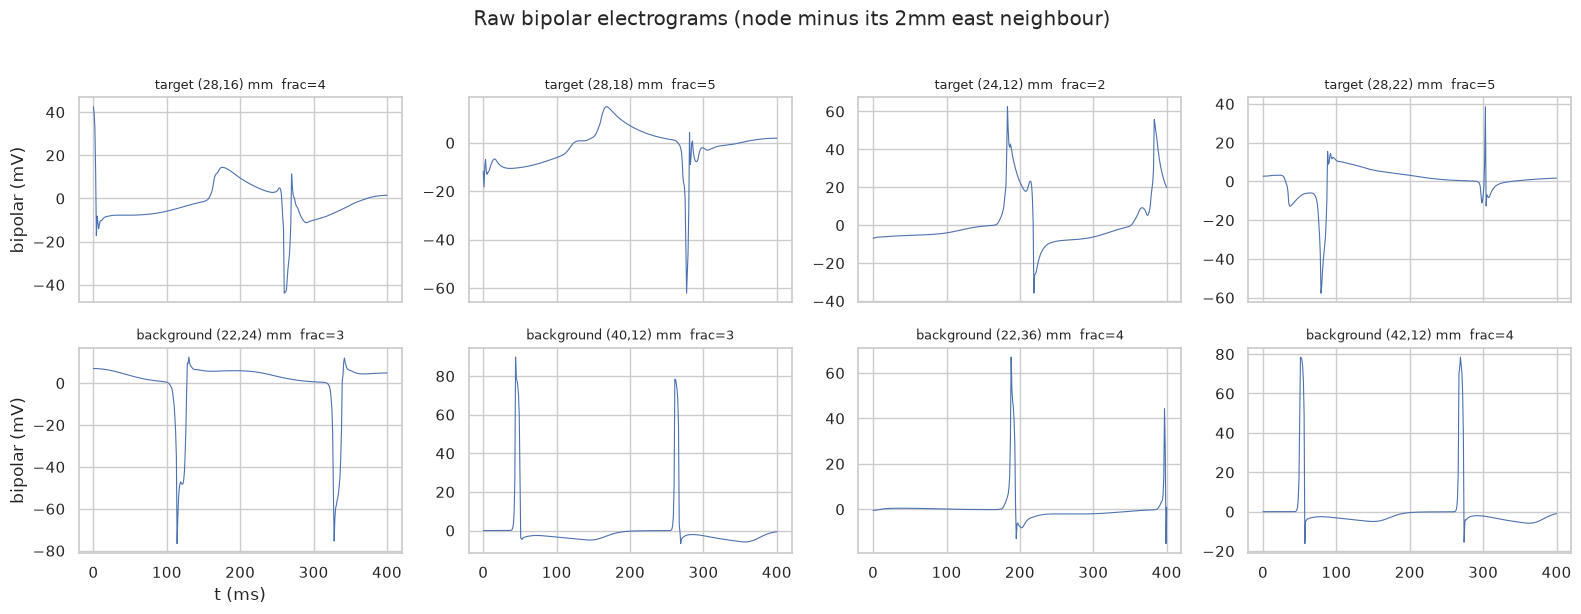

In [6]:
# worked example: raw bipolar traces, target sites vs background sites
nx_A, ny_A = grid_shape(pts_A)
bp_A = bipolar_east(vm_A, nx_A, ny_A)

def node_at(x_mm, y_mm):
    ix = int(round(x_mm * 1000 / 400)); iy = int(round(y_mm * 1000 / 400))
    return iy * nx_A + ix

k4A = cluster_df["A"][cluster_df["A"]["k"] == 4]
tgt = k4A[k4A["ablation_target"]].sample(4, random_state=1)
bg  = k4A[~k4A["ablation_target"]].sample(4, random_state=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for row, (grp, name) in enumerate([(tgt, "target"), (bg, "background")]):
    for ax, (_, rr) in zip(axes[row], grp.iterrows()):
        nid = node_at(rr["x_mm"], rr["y_mm"])
        bp = bp_A[nid]
        ax.plot(t_A, bp, lw=0.8)
        ax.set_title(f"{name} ({rr['x_mm']:.0f},{rr['y_mm']:.0f}) mm  "
                     f"frac={count_deflections(bp):.0f}", fontsize=9)
        ax.set_ylabel("bipolar (mV)" if ax is axes[row][0] else "")
axes[1, 0].set_xlabel("t (ms)")
fig.suptitle("Raw bipolar electrograms (node minus its 2mm east neighbour)", y=1.02)
fig.tight_layout()

**What the three checks show:**

- **Per-beat normalisation doesn't rescue it.** `frac_per_beat` overlaps just as heavily as
  `frac_raw` — and its correlation with distance-to-core stays near zero. The confound was
  real but small; removing it doesn't reveal a hidden signal.
- **Your eye can separate the classes but the metric can't.** In the worked-example traces,
  target electrograms are visibly *slower and multi-humped* (a drawn-out depolarisation with
  several bumps), background ones are a flat baseline with one or two crisp biphasic spikes.
  But the reversal *count* comes out ~3–5 for both — a clean biphasic spike plus baseline
  wiggle already spends 3–4 reversals, so the count saturates before it ever gets to the
  interesting part. A **duration**-based measure (time from first to last significant
  deflection per beat) or a slope/complexity measure would capture what the eye sees; the
  zero-crossing count does not.
- **Spatially** (next section's map) `fractionation` shows no coherent structure around the
  core.

Net: consistent with its near-zero permutation importance. `fractionation` as currently
defined is the wrong summary of a real underlying difference — a candidate for redefinition,
not just re-scaling.

## 3B. Dominant frequency: the spatial picture — and a window-length problem

Hypothesis worth testing directly: the ablation-target label is a hard 3 mm cut around the
core path, but the tissue almost certainly changes *gradually* with distance from the core.
If so, a feature like dominant frequency should show a smooth gradient, and the binary label
is throwing information away. Let's map DF (and, for context, raw activation count) onto the
actual tissue and see.

FFT frequency resolution over a 400 ms window = 2.49 Hz
distinct DF values that even exist in-band: [ 4.99  7.48  9.98 12.47 14.96]
rotor-A DF (unipolar) value counts:
4.987531    13314
7.481297      134
9.975062        8
Name: count, dtype: int64


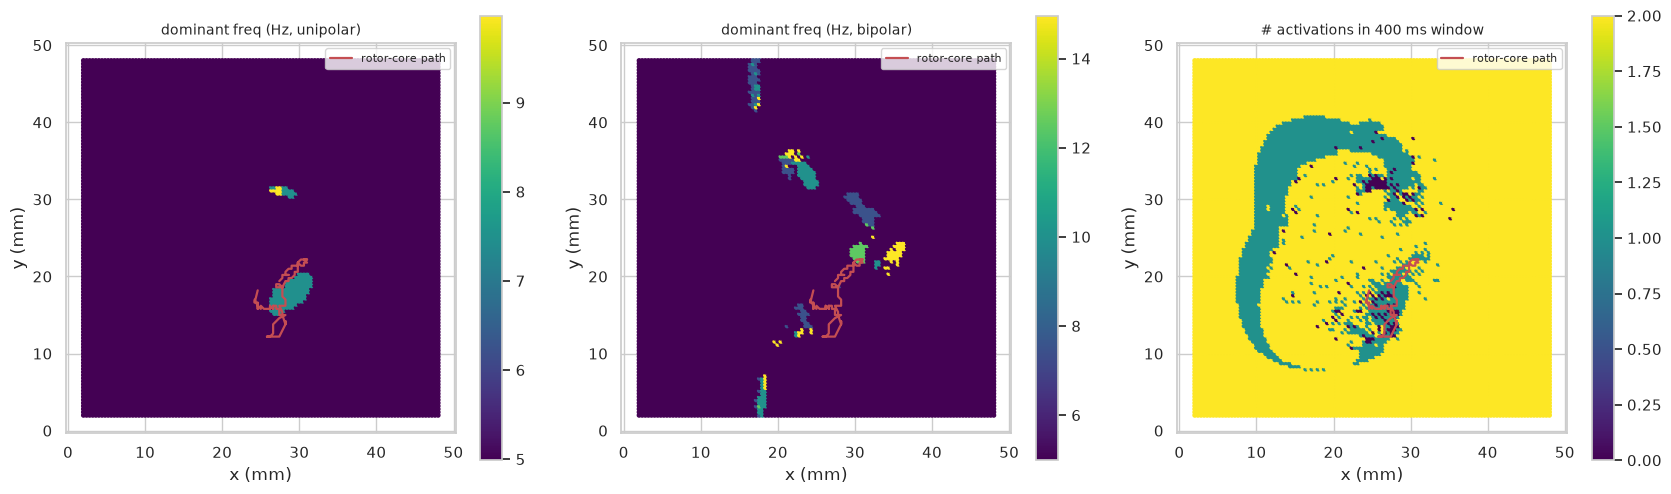

In [7]:
DF_BAND = (3.0, 15.0)

def dominant_freq_rows(sig, fs=FS_HZ, band=DF_BAND):
    sig = np.nan_to_num(sig, nan=0.0)
    sig = sig - sig.mean(axis=1, keepdims=True)
    n = sig.shape[1]
    spec = np.abs(np.fft.rfft(sig, axis=1))
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    m = (freqs >= band[0]) & (freqs <= band[1])
    return freqs[m][np.argmax(spec[:, m], axis=1)], freqs[m]

d = raw["A"]
pts_A0, vm_A0 = d["pts"], d["vm"].astype(float)
nx0, ny0 = grid_shape(pts_A0)
tx, ty = d["traj_x"], d["traj_y"]

df_uni, band_freqs = dominant_freq_rows(vm_A0)
df_bip, _ = dominant_freq_rows(bipolar_east(vm_A0, nx0, ny0))
acts_A = np.array([activation_count(row) for row in vm_A0])

# mask the border ring where the east-neighbour bipolar is undefined
ix = np.arange(len(pts_A0)) % nx0
iy = np.arange(len(pts_A0)) // nx0
interior = (ix >= BORDER) & (ix < nx0 - BORDER) & (iy >= BORDER) & (iy < ny0 - BORDER)

fs_resolution = band_freqs[1] - band_freqs[0]
print(f"FFT frequency resolution over a {vm_A0.shape[1]-1} ms window = {fs_resolution:.2f} Hz")
print(f"distinct DF values that even exist in-band: {np.round(band_freqs, 2)}")
print(f"rotor-A DF (unipolar) value counts:\n{pd.Series(df_uni[interior]).value_counts()}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, val, ttl in [(axes[0], df_uni, "dominant freq (Hz, unipolar)"),
                     (axes[1], df_bip, "dominant freq (Hz, bipolar)"),
                     (axes[2], acts_A.astype(float), "# activations in 400 ms window")]:
    v = np.where(interior, val, np.nan)
    sc = ax.scatter(pts_A0[:, 0] / 1000, pts_A0[:, 1] / 1000, c=v, s=7, cmap="viridis")
    ax.plot(tx / 1000, ty / 1000, "r-", lw=1.6, label="rotor-core path")
    ax.set_aspect("equal"); ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
    ax.set_title(ttl, fontsize=10); ax.legend(loc="upper right", fontsize=8)
    plt.colorbar(sc, ax=ax)
fig.tight_layout()

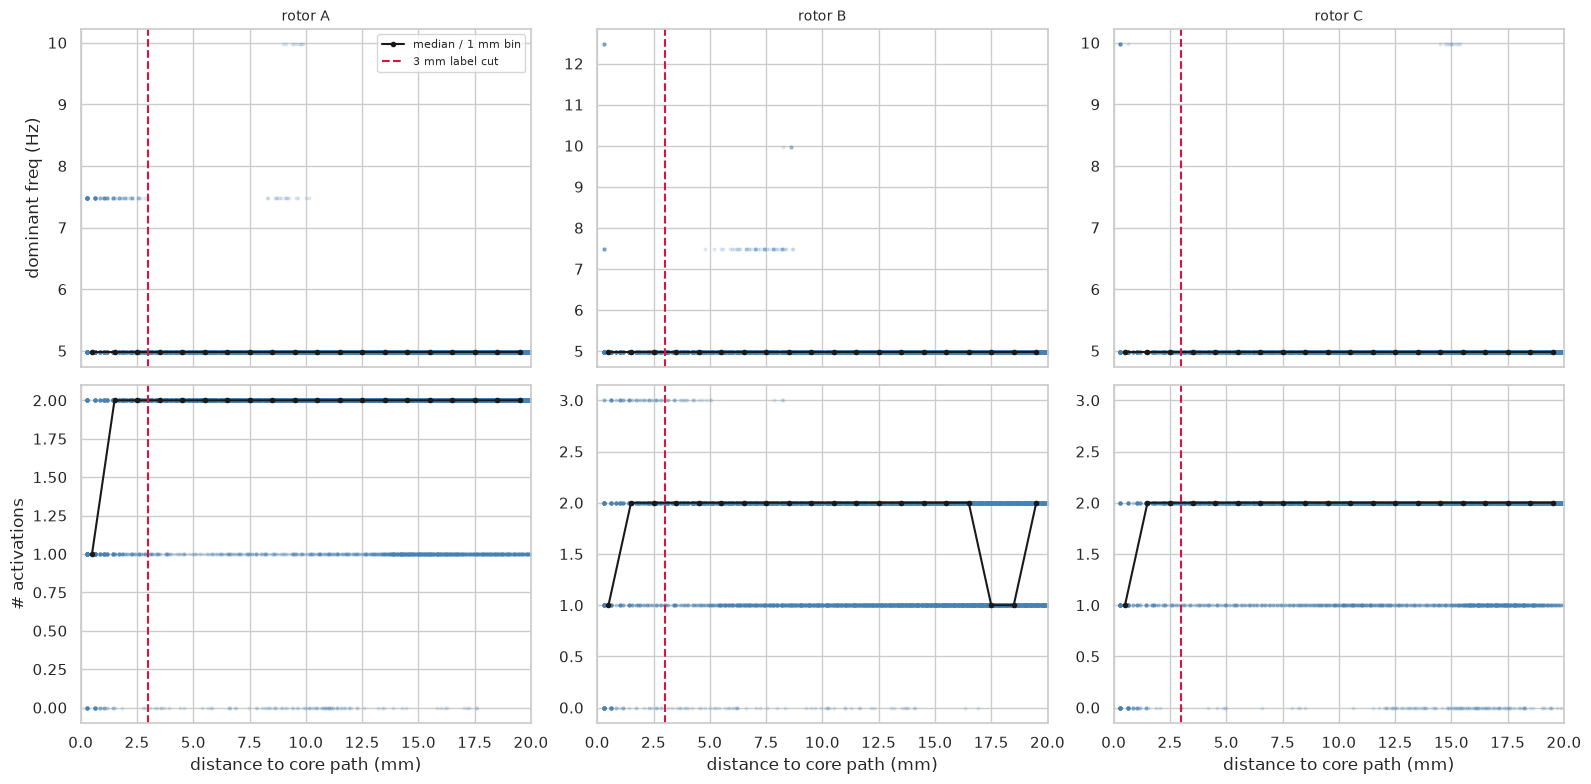

In [8]:
# DF and activation count vs distance-to-core, all 3 rotors
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for col, r in enumerate(ROTORS):
    d = raw[r]
    pts, vm = d["pts"], d["vm"].astype(float)
    dist = core_distance_mm(pts, d["traj_x"], d["traj_y"])
    dfreq, _ = dominant_freq_rows(vm)
    acts = np.array([activation_count(row) for row in vm])
    bins = np.arange(0, 20.5, 1.0); bc = 0.5 * (bins[:-1] + bins[1:])
    for row, val, lbl in [(0, dfreq, "dominant freq (Hz)"), (1, acts.astype(float), "# activations")]:
        ax = axes[row, col]
        ax.scatter(dist, val, s=4, alpha=0.12, color="steelblue")
        med = [np.median(val[(dist >= a) & (dist < b)]) for a, b in zip(bins[:-1], bins[1:])]
        ax.plot(bc, med, "k-o", ms=3, label="median / 1 mm bin")
        ax.axvline(3.0, color="crimson", ls="--", label="3 mm label cut")
        ax.set_xlim(0, 20)
        if row == 1:
            ax.set_xlabel("distance to core path (mm)")
        if col == 0:
            ax.set_ylabel(lbl)
        if row == 0:
            ax.set_title(f"rotor {r}", fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.tight_layout()

**The gradient isn't there — because the window is too short to look for it.**

- The rotor cycle length is ~200 ms and the simulation window is ~400 ms, so **every site is
  activated only 1–2 times**. You cannot estimate a ~5 Hz rhythm from one or two cycles.
- An FFT over a 400 ms window has a bin spacing of **2.5 Hz**. Inside the 3–15 Hz search
  band the *only* values `dominant_freq` can return are 5.0, 7.5, 10.0, 12.5 Hz. The map is
  not a gradient; it's a near-uniform field pinned at 5 Hz with a small blob near the core
  that tips to 7.5 Hz (where a site catches a third activation because the spiral arm sweeps
  back over it).
- Raw activation count (bottom row) is flat — ~1.5–2 everywhere, if anything slightly
  *lower* right at the core, where the tissue near the phase singularity never fully
  activates.

So `dom_freq_mean` is essentially constant across the tissue, and `dom_freq_std` across a
cluster is non-zero *only* where neighbours straddle the 5 → 7.5 Hz quantisation step —
which happens to concentrate near the core. It "works" in the classifier as a lossy,
quantisation-mediated proxy for core proximity, **not** as a measurement of a real frequency
gradient. This is the same class of problem as the `lat_spread_ms` finding in Section 2, and
it belongs in the methodology doc's caveats.

**To actually answer the gradient question** you need simulations with multi-second windows
(10–20 beats): then DF has sub-Hz resolution, a time-domain cycle-length estimate becomes
meaningful, and "hard boundary vs. gradient" is a question the data can settle. Until then,
the honest read is that the frequency features are core-proximity flags with most of their
nominal information content unresolvable.

## 4. Correlation and a 2D view

Two quick sanity checks: are any of the 9 features redundant with each other (high
correlation, not adding independent information)? And does a simple 2D projection show any
visual separation between the classes at all?

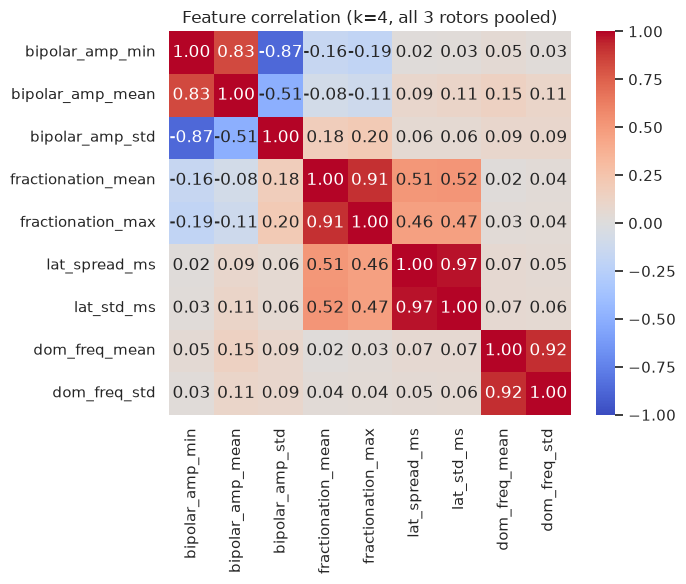

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = k4[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature correlation (k=4, all 3 rotors pooled)")
fig.tight_layout()

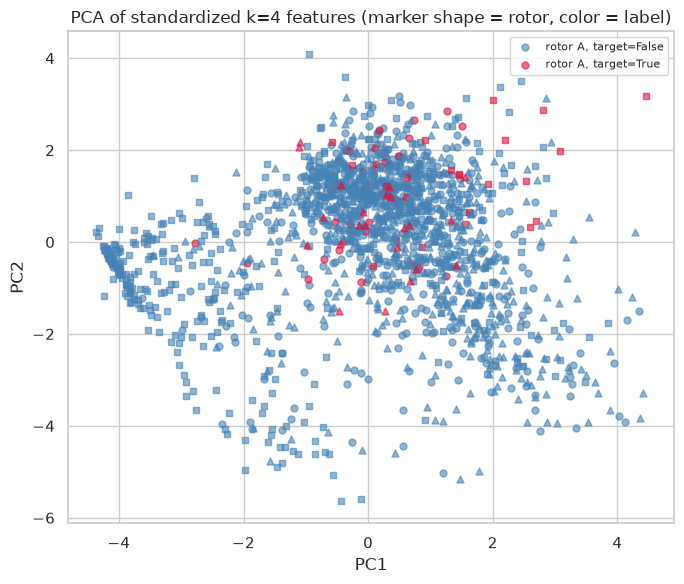

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(k4[FEATURES].values)
proj = PCA(n_components=2, random_state=42).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
for rotor, marker in zip(ROTORS, ["o", "s", "^"]):
    mask = k4["rotor"] == rotor
    for label, color in [(False, "steelblue"), (True, "crimson")]:
        m = mask & (k4["ablation_target"] == label)
        ax.scatter(proj[m, 0], proj[m, 1], c=color, marker=marker, alpha=0.6, s=25,
                   label=f"rotor {rotor}, target={label}" if rotor == "A" else None)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=8)
ax.set_title("PCA of standardized k=4 features (marker shape = rotor, color = label)")
fig.tight_layout()

## 5. Feature engineering playground

Three ideas for features not currently in the pipeline, ordered roughly by how directly they
extend the existing "relational" framing (§9 of the methodology doc):

1. **Organization Index** (implemented below) — the classic AF-literature measure of how
   "clean"/periodic a signal's dominant frequency really is: the ratio of spectral power at
   the dominant-frequency peak (and its harmonics) to the *total* spectral power in the
   signal. A value near 1 means the signal is almost purely periodic at that frequency; a low
   value means the spectrum is smeared out, which `fractionation`'s zero-crossing count only
   partially captures.
2. **Local conduction velocity** (scaffolded — your turn) — instead of just the *spread* in
   LAT across a cluster, estimate an actual velocity: distance between two opposite-direction
   neighbors, divided by their LAT difference. Slow/heterogeneous conduction (not just
   inconsistent timing) is a separate, well-documented marker of arrhythmogenic substrate.
3. **Sample entropy / signal complexity** (scaffolded — your turn) — a nonlinear time-series
   complexity measure, from a completely different mathematical family than
   `fractionation`'s zero-crossing counting. Worth checking whether it agrees with
   `fractionation` or catches something different.

In [11]:
def organization_index(bipolar, fs_hz, df_band=(3.0, 15.0), n_harmonics=3, harmonic_width_hz=0.5):
    # Fraction of spectral power at the dominant frequency and its first n_harmonics,
    # relative to total power in df_band. 1.0 = perfectly periodic within the band.
    n = len(bipolar)
    spectrum = np.abs(np.fft.rfft(bipolar - bipolar.mean())) ** 2
    freqs = np.fft.rfftfreq(n, d=1.0 / fs_hz)
    band = (freqs >= df_band[0]) & (freqs <= df_band[1])
    if not band.any() or spectrum[band].sum() == 0:
        return 0.0
    dom_freq = freqs[band][np.argmax(spectrum[band])]

    peak_power = 0.0
    for h in range(1, n_harmonics + 1):
        harmonic_mask = np.abs(freqs - h * dom_freq) <= harmonic_width_hz
        peak_power += spectrum[harmonic_mask].sum()
    return float(min(peak_power / spectrum[band].sum(), 1.0))


# quick test on the two clusters from Section 2
for cluster, name in [(near_core_cluster, "near-core"), (far_cluster, "background")]:
    for i, node in enumerate(cluster):
        oi = organization_index(vm_A[node] - vm_A[node].mean(), FS_HZ)
        print(f"  {name} site {i}: organization index = {oi:.3f}")

  near-core site 0: organization index = 0.893
  near-core site 1: organization index = 0.663
  near-core site 2: organization index = 0.711
  near-core site 3: organization index = 0.598
  near-core site 4: organization index = 0.505
  background site 0: organization index = 0.978
  background site 1: organization index = 0.977
  background site 2: organization index = 0.977
  background site 3: organization index = 0.979
  background site 4: organization index = 0.978


Run `organization_index` across a full rotor's electrode sites the same way
`extract_cluster_features.py` does (loop over candidate sites, compute per-site or
cluster-aggregated), add it to a copy of the `k4` dataframe, and rerun the Section 3-4
distribution/correlation plots with it included — does it separate the classes better or
worse than `dom_freq_std`? Does it correlate strongly with `fractionation_mean` (same
underlying idea, different math) or pick up something distinct?

In [12]:
def local_conduction_velocity(pts, nx, candidate_id, lat_all_ms, offset_nodes=OFFSET_NODES):
    # TODO: estimate a local conduction-velocity MAGNITUDE (mm/ms, or convert to m/s) at
    # candidate_id, using LAT differences to its cardinal neighbors and their known physical
    # spacing (offset_nodes * 0.4mm).
    #
    # Hints:
    #   - lat_all_ms is precomputed per-node LAT (see extract_cluster_features.py's
    #     "lat_idx_all = np.argmin(np.diff(vm, axis=1), axis=1)" for the vectorized version
    #     across the whole mesh at once, much faster than calling compute_lat node-by-node).
    #   - Velocity along one direction ~= distance / |LAT(neighbor) - LAT(candidate)|. Do
    #     this for both opposite-direction neighbor pairs (e.g. east vs. west) and think
    #     about how you want to combine them into one scalar -- an average? The minimum
    #     (slowest direction)? Something that also flags when the two opposite directions
    #     *disagree* in estimated velocity (which itself might be a meaningful additional
    #     feature -- another relational, "how internally consistent is this neighborhood"
    #     signal, same family as lat_spread_ms).
    #   - Watch for near-zero or negative LAT differences (division blows up, or the
    #     direction of "conduction" flips sign) -- decide how you want to handle that edge
    #     case.
    raise NotImplementedError("your turn")


def sample_entropy(signal, m=2, r_frac=0.2):
    # TODO: a classic nonlinear complexity measure (Richman & Moorman 2000). Roughly: for
    # embedding dimension m, count pairs of length-m subsequences that are 'similar' (within
    # r_frac * std(signal) of each other pointwise), then the analogous count for
    # length-(m+1) subsequences; sample entropy is -log(count_{m+1} / count_m). Higher = more
    # complex/irregular. scipy/numpy don't have this built in -- there are reference
    # implementations in the 'nolds' or 'antropy' packages if you'd rather not hand-roll it
    # (neither is currently in requirements.txt).
    raise NotImplementedError("your turn")

## 6. Model formulation: a cleaner cross-rotor evaluation, and alternative models

`opencarp/train_leave_one_rotor_out.py` hand-rolls leave-one-rotor-out cross-validation. Since
we already have a `rotor` column, sklearn's `GroupKFold` (or `LeaveOneGroupOut`, since we only
have 3 groups) does the same thing idiomatically, and makes it trivial to swap in different
model classes for comparison.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.pipeline import make_pipeline

all_k = pd.concat(
    [cluster_df[r].assign(rotor=r) for r in ROTORS], ignore_index=True
)

def eval_model(model, k, use_scaler=False):
    df = all_k[all_k["k"] == k]
    X, y, groups = df[FEATURES].values, df["ablation_target"].values.astype(int), df["rotor"].values
    pipe = make_pipeline(StandardScaler(), model) if use_scaler else model
    logo = LeaveOneGroupOut()
    scores = cross_val_score(pipe, X, y, groups=groups, cv=logo, scoring="roc_auc")
    return scores

models = {
    "HistGBM (current)": (HistGradientBoostingClassifier(max_depth=4, max_iter=200,
                                                            learning_rate=0.05, random_state=42), False),
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=1000), True),
    "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=5,
                                               class_weight="balanced", random_state=42), False),
}

rows = []
for k in sorted(all_k["k"].unique()):
    for name, (model, scaler) in models.items():
        scores = eval_model(model, k, use_scaler=scaler)
        rows.append({"k": k, "model": name, "mean_auc": scores.mean(), "std_auc": scores.std()})

comparison = pd.DataFrame(rows)
comparison.pivot(index="k", columns="model", values="mean_auc").round(3)

model,HistGBM (current),Logistic Regression,Random Forest
k,,,
1,0.705,0.413,0.662
2,0.842,0.493,0.834
3,0.728,0.561,0.725
4,0.787,0.605,0.766
5,0.755,0.635,0.689
6,0.783,0.675,0.723
7,0.787,0.686,0.726
8,0.754,0.665,0.776


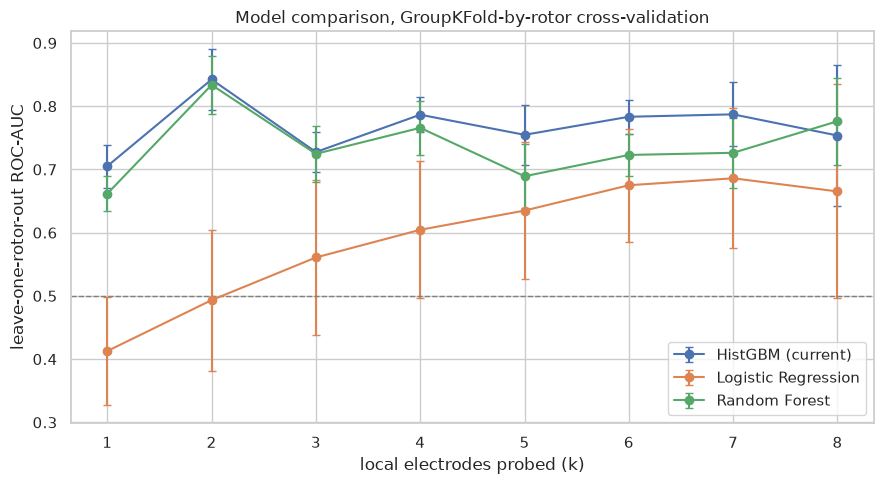

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for name in models:
    sub = comparison[comparison["model"] == name]
    ax.errorbar(sub["k"], sub["mean_auc"], yerr=sub["std_auc"], marker="o", capsize=3, label=name)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("local electrodes probed (k)")
ax.set_ylabel("leave-one-rotor-out ROC-AUC")
ax.legend()
ax.set_title("Model comparison, GroupKFold-by-rotor cross-validation")
fig.tight_layout()

Sanity check: the "HistGBM (current)" line should roughly reproduce
`results/phase2_reentry_2026-08-20/leave_one_rotor_out.png`'s mean curve (small differences
are expected — that script also repeats with 10 checkerboard-phase jitters per rotor for
the *within*-rotor spatial numbers, which isn't quite the same evaluation as this notebook's
`LeaveOneGroupOut`, but the leave-one-rotor-out numbers specifically should line up closely).

Logistic Regression is worth a close look if it's competitive: `model.coef_` gives you signed,
directly interpretable coefficients (in standardized-feature units) — a stronger
"explain this to a domain expert" story than permutation importance on a tree ensemble, *if*
its AUC holds up. If it doesn't, that's useful information too — it'd suggest the true
decision boundary here isn't well-approximated by a linear one, which motivates keeping the
tree ensemble.

## 7. Where to take this next

- Finish `local_conduction_velocity` and `sample_entropy` above, add them to the feature set,
  and rerun Section 6's comparison — do they move the leave-one-rotor-out AUC at k=2 (the
  current best, most stable operating point)?
- `k=2`'s consistent edge over larger clusters (§12 of the methodology doc) was a genuine,
  somewhat surprising finding — worth specifically checking whether a *combination* of a
  couple of hand-picked directions (rather than always "the first k in a fixed
  E,N,W,S,... order") does even better, since the current sweep always adds neighbors in the
  same fixed order regardless of which directions actually matter for a given site.
- All of this is still bounded by 3 rotors / ~22-33 positive sites each. If you want tighter
  confidence intervals on any of the model-comparison numbers above, more independently
  induced rotors (`opencarp/README.md` §"multi-rotor runs") is the highest-leverage next step
  before trusting any specific number here strongly.